In [228]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
C:\Users\colla\anaconda3\envs\comp641\python.exe


In [229]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 2.4.2
Pandas: 2.3.3
Scikit-learn: 1.8.0
Matplotlib: 3.10.8


In [230]:
import os

project_folder = r"C:\Users\colla\OneDrive\Desktop\Data Science - Master of Science\COMP 542\Project"

os.chdir(project_folder)

print("Current folder:")
print(os.getcwd())

print("\nFiles in project folder:")
print(os.listdir())

Current folder:
C:\Users\colla\OneDrive\Desktop\Data Science - Master of Science\COMP 542\Project

Files in project folder:
['adult.data.csv', 'Daniel.ipynb', 'JP_initial_draft.ipynb']


In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [232]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(
    "adult.data.csv",
    header=None,
    names=columns,
    skipinitialspace=True
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [233]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["income"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Missing values:
age               0
workclass         0
fnlwgt            0
education  

In [234]:
df = df.replace("?", np.nan)

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [235]:
X = df.drop(columns="income")

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nEncoded target distribution:")
print(y.value_counts())

Feature shape: (32561, 14)
Target shape: (32561,)

Encoded target distribution:
income
0    24720
1     7841
Name: count, dtype: int64


In [236]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [237]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training feature shape: (26048, 14)
Testing feature shape: (6513, 14)

Training target distribution:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64

Testing target distribution:
income
0    0.759251
1    0.240749
Name: proportion, dtype: float64


In [238]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [239]:
# ---

In [240]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [241]:
rf_predictions = random_forest_model.predict(X_test)

rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(rf_predictions))

Predictions generated successfully.
Number of predictions: 6513


In [242]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy:  0.8580
Precision: 0.7352
Recall:    0.6409
F1-score:  0.6848
ROC-AUC:   0.9082


In [243]:
print("Random Forest Classification Report")
print("-----------------------------------")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["<=50K", ">50K"]
    )
)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.64      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.80      6513
weighted avg       0.85      0.86      0.85      6513



Random Forest Confusion Matrix:
[[4583  362]
 [ 563 1005]]


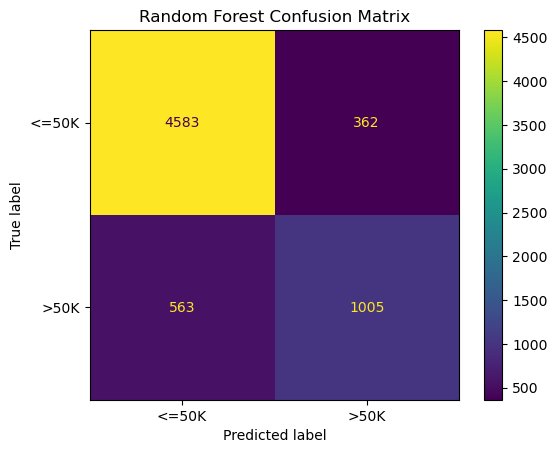

In [244]:
rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_predictions
)

print("Random Forest Confusion Matrix:")
print(rf_confusion_matrix)

ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=["<=50K", ">50K"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Random Forest Interpretation
The Random Forest classifier achieved approximately 86% accuracy on the test set. The confusion matrix shows that the model correctly classified 4,583 individuals earning $50K or less and 1,005 individuals earning more than $50K.
It produced 362 false positives and 563 false negatives.

The model performed more strongly on the majority income class (`<=50K`) than on the minority class (`>50K`). 
This indicates that accuracy alone should not be used to evaluate performance; precision, recall, F1-score, and ROC-AUC are also needed to assess how well the model identifies higher-income individuals.

In [246]:
# Create the Neural Network pipeline

neural_network_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(100,),
                activation="relu",
                solver="adam",
                max_iter=500,
                random_state=42
            )
        )
    ]
)

neural_network_model.fit(X_train, y_train)

print("Neural Network training completed successfully.")

Neural Network training completed successfully.


In [247]:
nn_predictions = neural_network_model.predict(X_test)

nn_probabilities = neural_network_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(nn_predictions))

Predictions generated successfully.
Number of predictions: 6513


In [248]:
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_precision = precision_score(y_test, nn_predictions)
nn_recall = recall_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions)
nn_roc_auc = roc_auc_score(y_test, nn_probabilities)

print("Neural Network Performance")
print("--------------------------")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-score:  {nn_f1:.4f}")
print(f"ROC-AUC:   {nn_roc_auc:.4f}")

Neural Network Performance
--------------------------
Accuracy:  0.8386
Precision: 0.6911
Recall:    0.5963
F1-score:  0.6402
ROC-AUC:   0.8877


In [249]:
print("Neural Network Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        nn_predictions,
        target_names=["<=50K", ">50K"]
    )
)

Neural Network Classification Report
------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4945
        >50K       0.69      0.60      0.64      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.76      0.77      6513
weighted avg       0.83      0.84      0.83      6513



Neural Network Confusion Matrix:
[[4527  418]
 [ 633  935]]


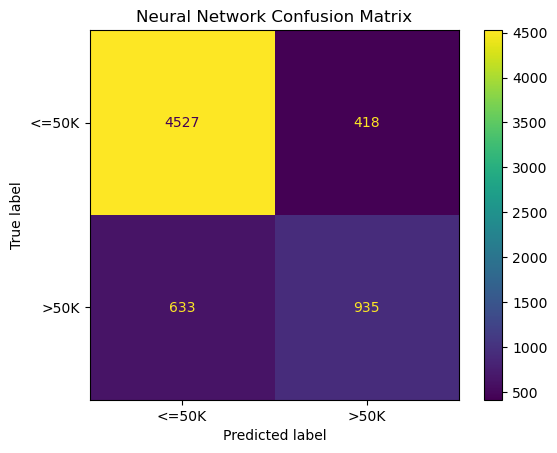

In [250]:
nn_confusion_matrix = confusion_matrix(
    y_test,
    nn_predictions
)

print("Neural Network Confusion Matrix:")
print(nn_confusion_matrix)

ConfusionMatrixDisplay(
    confusion_matrix=nn_confusion_matrix,
    display_labels=["<=50K", ">50K"]
).plot()

plt.title("Neural Network Confusion Matrix")
plt.show()

In [251]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ],
    "Neural Network": [
        nn_accuracy,
        nn_precision,
        nn_recall,
        nn_f1,
        nn_roc_auc
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)

comparison

,Metric,Random Forest,Neural Network
0,Accuracy,0.8580,0.8386
1,Precision,0.7352,0.6911
2,Recall,0.6409,0.5963
3,F1-score,0.6848,0.6402
4,ROC-AUC,0.9082,0.8877


In [253]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Random Forest Cross Validation Scores")
print(rf_cv_scores)

print("Mean Accuracy:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest Cross Validation Scores
[0.85214187 0.84720516 0.85242629 0.85933661 0.85703317]
Mean Accuracy: 0.8536286197214341
Standard Deviation: 0.004221112763328396


In [254]:
nn_cv_scores = cross_val_score(
    neural_network_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Neural Network Cross Validation Scores")
print(nn_cv_scores)

print("Mean Accuracy:", nn_cv_scores.mean())
print("Standard Deviation:", nn_cv_scores.std())

Neural Network Cross Validation Scores
[0.82880393 0.83108108 0.83277027 0.83538084 0.83814496]
Mean Accuracy: 0.8332362160954976
Standard Deviation: 0.0032619643354179937


In [255]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    random_forest_model,
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("Best Cross Validation Accuracy:")
print(rf_grid.best_score_)

Best Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best Cross Validation Accuracy:
0.8618702165048019


In [256]:
nn_param_grid = {
    "classifier__hidden_layer_sizes": [(50,), (100,), (100,50)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__learning_rate": ["constant", "adaptive"]
}

nn_grid = GridSearchCV(
    neural_network_model,
    nn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

nn_grid.fit(X_train, y_train)

print("Best Parameters:")
print(nn_grid.best_params_)

print("Best Cross Validation Accuracy:")
print(nn_grid.best_score_)

Best Parameters:
{'classifier__activation': 'relu', 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant'}
Best Cross Validation Accuracy:
0.8333844014991033


In [257]:
best_rf_predictions = best_rf.predict(X_test)
best_rf_probabilities = best_rf.predict_proba(X_test)[:, 1]

best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
best_rf_precision = precision_score(y_test, best_rf_predictions)
best_rf_recall = recall_score(y_test, best_rf_predictions)
best_rf_f1 = f1_score(y_test, best_rf_predictions)
best_rf_auc = roc_auc_score(y_test, best_rf_probabilities)

In [258]:
print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"Accuracy:  {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall:    {best_rf_recall:.4f}")
print(f"F1-score:  {best_rf_f1:.4f}")
print(f"ROC-AUC:   {best_rf_auc:.4f}")

Tuned Random Forest Performance
--------------------------------
Accuracy:  0.8696
Precision: 0.7911
Recall:    0.6231
F1-score:  0.6971
ROC-AUC:   0.9209


In [259]:
best_nn_predictions = best_nn.predict(X_test)
best_nn_probabilities = best_nn.predict_proba(X_test)[:, 1]

best_nn_accuracy = accuracy_score(y_test, best_nn_predictions)
best_nn_precision = precision_score(y_test, best_nn_predictions)
best_nn_recall = recall_score(y_test, best_nn_predictions)
best_nn_f1 = f1_score(y_test, best_nn_predictions)
best_nn_auc = roc_auc_score(y_test, best_nn_probabilities)

print("Tuned Neural Network Performance")
print("--------------------------------")
print(f"Accuracy:  {best_nn_accuracy:.4f}")
print(f"Precision: {best_nn_precision:.4f}")
print(f"Recall:    {best_nn_recall:.4f}")
print(f"F1-score:  {best_nn_f1:.4f}")
print(f"ROC-AUC:   {best_nn_auc:.4f}")

Tuned Neural Network Performance
--------------------------------
Accuracy:  0.8449
Precision: 0.6782
Recall:    0.6773
F1-score:  0.6777
ROC-AUC:   0.8993


In [260]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Baseline",
        "Random Forest - Tuned",
        "Neural Network - Baseline",
        "Neural Network - Tuned"
    ],
    "Accuracy": [
        rf_accuracy,
        best_rf_accuracy,
        nn_accuracy,
        best_nn_accuracy
    ],
    "Precision": [
        rf_precision,
        best_rf_precision,
        nn_precision,
        best_nn_precision
    ],
    "Recall": [
        rf_recall,
        best_rf_recall,
        nn_recall,
        best_nn_recall
    ],
    "F1-score": [
        rf_f1,
        best_rf_f1,
        nn_f1,
        best_nn_f1
    ],
    "ROC-AUC": [
        rf_roc_auc,
        best_rf_auc,
        nn_roc_auc,
        best_nn_auc
    ]
})

tuning_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest - Baseline,0.8580,0.7352,0.6409,0.6848,0.9082
1,Random Forest - Tuned,0.8696,0.7911,0.6231,0.6971,0.9209
2,Neural Network - Baseline,0.8386,0.6911,0.5963,0.6402,0.8877
3,Neural Network - Tuned,0.8449,0.6782,0.6773,0.6777,0.8993
